# Which window size T fits the links?

This notebook measures how long the links in the prepared data are, where a link is everything one receiving
car heard from one sender pseudonym. It then checks how much data each window size T keeps, with and without
padding, and how balanced the classes and splits are for each choice. The goal is to pick T from evidence
rather than from a default.

In [1]:
import json
import multiprocessing as mp
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Work from the repo root: data paths are relative to it (RULE 5).
for _folder in [Path.cwd(), *Path.cwd().parents]:  # notebooks live in src/<folder>/; work from the repo root
    if (_folder / "CLAUDE.md").is_file():
        os.chdir(_folder)
        break
assert Path("CLAUDE.md").is_file() and Path("data").is_dir(), f"run from the repo root, not {Path.cwd()}"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (9, 4.5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## Settings

The class order, the two classes the current encoder input uses, the grid of window sizes to compare and one
colour per class (used in every plot). The prepared data is read-only.

In [2]:
PREPARED_DIR = Path("src/data/prepared_data")
CLASS_ORDER = ["Benign", "GridSybil", "DataReplay", "DoSRandom", "DoSDisruptive"]
ENCODER_CLASSES = ["Benign", "GridSybil"]
T_GRID = [2, 4, 8, 12, 16, 20, 24, 32, 48, 64, 96, 128]
T_MARKS = [16, 20, 32, 64]
CLASS_COLOURS = {
    "Benign": "#16A34A",
    "GridSybil": "#BE185D",
    "DataReplay": "#0284C7",
    "DoSRandom": "#7C3AED",
    "DoSDisruptive": "#EA580C",
}
CODE_TO_CLASS = {0: "Benign", 16: "GridSybil", 17: "DataReplay", 18: "DoSRandom", 19: "DoSDisruptive", -1: "Unknown"}

## Load every link's length

`LinkTable` reads all prepared files in parallel and keeps one row per link: who heard it, who sent it, how many
messages it has and when it started. The class comes from the sender vehicle's label in `index.json` and the
split from the sender vehicle's split, so a link inherits both from its sender.

In [3]:
def read_link_rows(path: str) -> list[tuple]:
    """Reads one prepared file and returns one row per link (without the feature values).

    Top-level so that a forked worker pool can call it.

    Args:
        path: Path of a prepared `traceJSON-*.json` file.

    Returns:
        Tuples `(run, receiver, sender, sender_pseudo, n_messages, t_start)`.
    """
    with open(path) as handle:
        record = json.load(handle)
    rows = []
    for link in record["links"]:
        times = link["rcv_time"]
        rows.append(
            (
                record["run"],
                int(record["receiver"]),
                int(link["sender"]),
                int(link["sender_pseudo"]),
                len(link["message_id"]),
                float(times[0]) if times else np.nan,
            )
        )
    return rows


class LinkTable:
    """Builds the `links` table (one row per link) from the prepared data folder.

    Attributes:
        root: Folder holding the scenario folders and `index.json`.
        index: Parsed `index.json` (labels and split).
    """

    def __init__(self, root: Path, workers: int | None = None) -> None:
        """Initialises the reader.

        Args:
            root: The prepared data folder.
            workers: Worker processes; defaults to the CPU count.
        """
        self.root = root
        self.workers = workers or os.cpu_count() or 1
        self.index = json.loads((root / "index.json").read_text())

    def files(self) -> list[str]:
        """Returns every prepared trace file, sorted for a stable row order."""
        return sorted(str(p) for p in self.root.glob("*/*/traceJSON-*.json"))

    def _read_all(self, paths: list[str]) -> list[tuple]:
        """Reads all files with a forked pool and flattens the rows."""
        with mp.get_context("fork").Pool(self.workers) as pool:
            chunks = pool.map(read_link_rows, paths, chunksize=64)
        return [row for chunk in chunks for row in chunk]

    def _split_lookup(self) -> dict[str, str]:
        """Maps `"<group>:<vehicle>"` to its split name."""
        return {key: split for split, keys in self.index["split"]["vehicles"].items() for key in keys}

    def build(self) -> pd.DataFrame:
        """Reads the data and returns the `links` table with labels and split attached."""
        paths = self.files()
        frame = pd.DataFrame(
            self._read_all(paths), columns=["run", "receiver", "sender", "sender_pseudo", "n_messages", "t_start"]
        )
        frame["scenario"] = frame["run"].str.split("/").str[0]
        frame["group"] = frame["scenario"].str.rsplit("_", n=1).str[1]
        labels = self.index["labels"]
        frame["code"] = [labels.get(s, {}).get(str(v), -1) for s, v in zip(frame["scenario"], frame["sender"])]
        frame["cls"] = frame["code"].map(CODE_TO_CLASS).fillna("Unknown")
        lookup = self._split_lookup()
        frame["split"] = [lookup.get(f"{g}:{v}", "none") for g, v in zip(frame["group"], frame["sender"])]
        self.n_files = len(paths)
        columns = [
            "scenario",
            "group",
            "run",
            "receiver",
            "sender",
            "sender_pseudo",
            "n_messages",
            "code",
            "cls",
            "split",
            "t_start",
        ]
        return frame[columns]


link_table = LinkTable(PREPARED_DIR)
links = link_table.build()
print(
    f"{link_table.n_files:,} files -> {len(links):,} links, {links['n_messages'].sum():,} messages; "
    f"{(links['cls'] == 'Unknown').sum():,} links from unlabeled senders, "
    f"{(links['split'] == 'none').sum():,} links from senders outside every split"
)
links.head()

23,032 files -> 5,321,657 links, 20,364,658 messages; 271 links from unlabeled senders, 0 links from senders outside every split


,scenario,group,run,receiver,sender,sender_pseudo,n_messages,code,cls,split,t_start
0,DataReplaySybil_0709,0709,DataReplaySybil_0709/VeReMi_25200_28800_2022-9...,10005,9489,1094892,23,0,Benign,val,"28,468.32"
1,DataReplaySybil_0709,0709,DataReplaySybil_0709/VeReMi_25200_28800_2022-9...,10005,9543,1095432,17,0,Benign,test,"28,468.09"
2,DataReplaySybil_0709,0709,DataReplaySybil_0709/VeReMi_25200_28800_2022-9...,10005,9645,1096452,9,0,Benign,val,"28,492.51"
3,DataReplaySybil_0709,0709,DataReplaySybil_0709/VeReMi_25200_28800_2022-9...,10005,9663,1096632,17,0,Benign,train,"28,484.34"
4,DataReplaySybil_0709,0709,DataReplaySybil_0709/VeReMi_25200_28800_2022-9...,10005,9687,1096872,2,0,Benign,pretrain_val,"28,557.61"


## How long are links? Summary per class

One row per class: how many links and messages it has and the length percentiles (in messages, 1 message per
second). The second table repeats this per scenario folder, so you can see whether a class behaves the same
in both time windows. Read the median and p90 against the candidate T values: a link shorter than T gives no
full window without padding.

In [4]:
class LengthSummary:
    """Percentile tables of link length."""

    PERCENTILES = {"median": 0.50, "p75": 0.75, "p90": 0.90, "p99": 0.99}

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame

    def table(self, by: list[str]) -> pd.DataFrame:
        """Returns links, messages, length percentiles and max per group."""
        grouped = self.frame.groupby(by, observed=True)["n_messages"]
        out = pd.DataFrame({"links": grouped.size(), "messages": grouped.sum()})
        for name, q in self.PERCENTILES.items():
            out[name] = grouped.quantile(q)
        out["max"] = grouped.max()
        return out


def ordered_classes(frame: pd.DataFrame) -> list[str]:
    """Class order used in tables: CLASS_ORDER first, then anything else present (e.g. Unknown)."""
    present = set(frame["cls"])
    return [c for c in CLASS_ORDER if c in present] + sorted(present - set(CLASS_ORDER))


summary = LengthSummary(links)
by_class = summary.table(["cls"]).reindex(ordered_classes(links))
display(by_class)
by_scenario = summary.table(["scenario", "cls"])
display(by_scenario)
print(
    "Takeaway: median link length is "
    + ", ".join(f"{c} {by_class.loc[c, 'median']:.0f}" for c in CLASS_ORDER if c in by_class.index)
    + f" messages; only {(links['n_messages'] >= 64).mean():.1%} of all links reach 64 messages."
)

,links,messages,median,p75,p90,p99,max
cls,,,,,,,
Benign,502282,10445832,14.00,26.00,46.00,119.00,272
GridSybil,228527,4364413,11.00,23.00,44.00,125.00,861
DataReplay,732657,1112508,1.00,2.00,2.00,6.00,66
DoSRandom,1928981,2218891,1.00,1.00,2.00,3.00,7
DoSDisruptive,1928939,2218891,1.00,1.00,2.00,3.00,7
Unknown,271,4123,11.00,19.00,32.00,74.50,162


links  messages  median   p75   p90    p99  max
scenario                cls                                                             
DataReplaySybil_0709    Benign          103860   2081685   14.00 25.00 44.00 111.00  226
                        DataReplay      588828    873068    1.00  2.00  2.00   6.00   14
DataReplaySybil_1416    Benign           21658    528518   16.00 30.00 59.00 137.00  272
                        DataReplay      143829    239440    1.00  2.00  3.00   6.00   66
DoSDisruptiveSybil_0709 Benign          103859   2081446   14.00 25.00 44.00 111.00  226
                        DoSDisruptive  1547646   1741441    1.00  1.00  2.00   3.00    5
DoSDisruptiveSybil_1416 Benign           21688    528397   16.00 30.00 59.00 136.13  270
                        DoSDisruptive   381293    477450    1.00  1.00  2.00   3.00    7
DoSRandomSybil_0709     Benign          103859   2081446   14.00 25.00 44.00 111.00  226
                        DoSRandom      1547664   1741441    1.00  1.00  2.00   3.00    5
DoSRandomSybil_1416     Benign           21688    528397   16.00 30.00 59.00 136.13  270
                        DoSRandom       381317    477450    1.00  1.00  2.00   3.00    7
GridSybil_0709          Benign          103971   2088408   14.00 26.00 44.00 110.00  191
                        GridSybil       184785   3390580   11.00 22.00 41.00 120.00  861
                        Unknown            271      4123   11.00 19.00 32.00  74.50  162
GridSybil_1416          Benign           21699    527535   16.00 30.00 59.00 136.00  270
                        GridSybil        43742    973833   12.00 27.00 55.00 136.00  538

Takeaway: median link length is Benign 14, GridSybil 11, DataReplay 1, DoSRandom 1, DoSDisruptive 1 messages; only 0.7% of all links reach 64 messages.


## Length buckets

The share of each class's links that falls into each length bucket (rows sum to 100%). This shows where the
mass is: a class whose links are mostly 1–2 messages long cannot fill any reasonable window, whatever T is.

In [5]:
BUCKET_EDGES = [0, 1, 2, 4, 8, 16, 32, 64, 128, np.inf]
BUCKET_LABELS = ["1", "2", "3–4", "5–8", "9–16", "17–32", "33–64", "65–128", ">128"]
length_bucket = pd.cut(links["n_messages"], BUCKET_EDGES, labels=BUCKET_LABELS, right=True)
bucket_pct = (pd.crosstab(links["cls"], length_bucket, normalize="index") * 100).reindex(ordered_classes(links))
display(bucket_pct.round(1))
short = bucket_pct[["1", "2"]].sum(axis=1)
print(
    "Takeaway: links of 1–2 messages make up "
    + ", ".join(f"{c} {short[c]:.0f}%" for c in CLASS_ORDER if c in short.index)
    + "."
)

n_messages,1,2,3–4,5–8,9–16,17–32,33–64,65–128,>128
cls,,,,,,,,,
Benign,5.50,4.70,7.90,13.60,23.70,27.40,12.10,4.40,0.70
GridSybil,8.70,6.70,10.70,16.00,21.40,21.10,10.30,4.10,0.90
DataReplay,68.90,22.30,5.10,3.60,0.10,0.00,0.00,0.00,0.00
DoSRandom,87.80,9.70,2.50,0.00,0.00,0.00,0.00,0.00,0.00
DoSDisruptive,87.80,9.70,2.50,0.00,0.00,0.00,0.00,0.00,0.00
Unknown,6.30,7.40,10.00,16.60,30.60,19.90,7.00,1.80,0.40


Takeaway: links of 1–2 messages make up Benign 10%, GridSybil 15%, DataReplay 91%, DoSRandom 97%, DoSDisruptive 97%.


## Length distribution plots

Left: histogram of link length per class on a log x-axis (each class normalised to its own total, so shapes
are comparable). Right: for each class, the share of links (solid) and the share of messages (dashed) that sit
in links of length ≤ L. The dashed lines at T = 16, 20, 32, 64 mark candidate window sizes: the gap between a
curve and 1 at a line is roughly what that T could still use without padding. DoSRandom and DoSDisruptive have
practically identical link lengths in this data (same message totals), so their lines lie on top of each other.

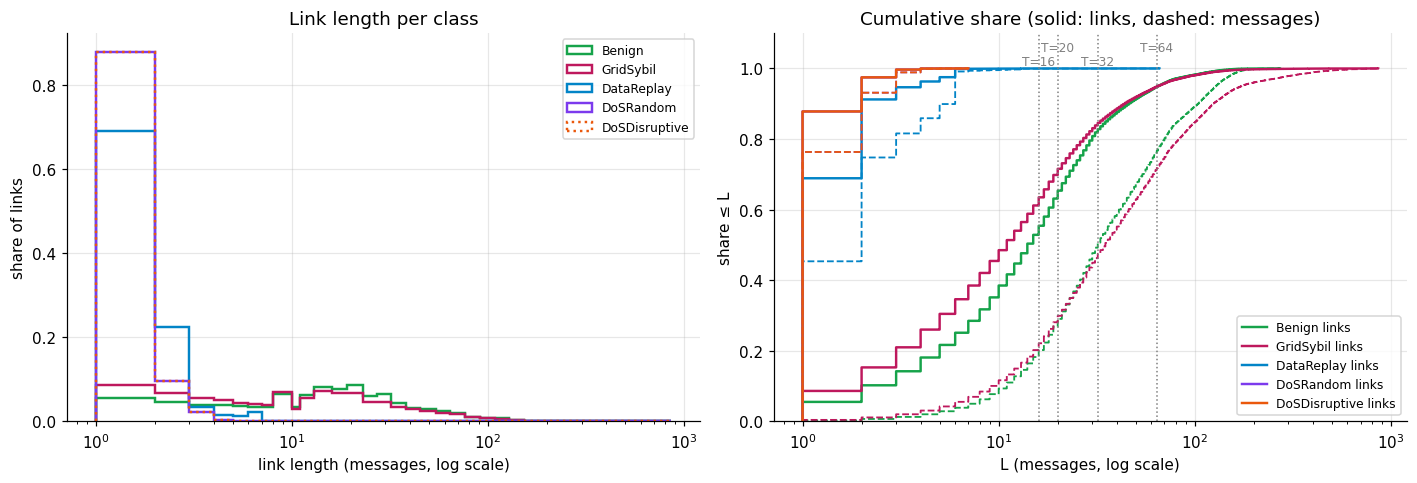

Takeaway (GridSybil folders, Benign + GridSybil): T=16: 42% of links and 81% of messages are in links of length ≥ T.
Takeaway (GridSybil folders, Benign + GridSybil): T=20: 33% of links and 72% of messages are in links of length ≥ T.
Takeaway (GridSybil folders, Benign + GridSybil): T=32: 17% of links and 53% of messages are in links of length ≥ T.
Takeaway (GridSybil folders, Benign + GridSybil): T=64: 5% of links and 27% of messages are in links of length ≥ T.


In [6]:
class LengthPlots:
    """Histogram and cumulative curves of link length per class."""

    def __init__(self, frame: pd.DataFrame, classes: list[str]) -> None:
        self.frame = frame
        self.classes = classes

    def histogram(self, ax: plt.Axes) -> None:
        """Log-binned histogram of link length per class."""
        bins = np.unique(np.logspace(0, np.log10(self.frame["n_messages"].max() + 1), 40).round())
        for cls in self.classes:
            lengths = self.frame.loc[self.frame["cls"] == cls, "n_messages"]
            ax.hist(
                lengths,
                bins=bins,
                histtype="step",
                lw=1.6,
                color=CLASS_COLOURS[cls],
                ls=":" if cls == "DoSDisruptive" else "-",
                weights=np.full(len(lengths), 1 / len(lengths)),
                label=cls,
            )
        ax.set(
            xscale="log",
            xlabel="link length (messages, log scale)",
            ylabel="share of links",
            title="Link length per class",
        )
        ax.legend(fontsize=8)

    def cumulative(self, ax: plt.Axes) -> None:
        """Share of links / messages in links of length ≤ L per class."""
        for cls in self.classes:
            lengths = np.sort(self.frame.loc[self.frame["cls"] == cls, "n_messages"].to_numpy())
            share_links = np.arange(1, len(lengths) + 1) / len(lengths)
            share_msgs = np.cumsum(lengths) / lengths.sum()
            ax.step(lengths, share_links, where="post", color=CLASS_COLOURS[cls], lw=1.6, label=f"{cls} links")
            ax.step(lengths, share_msgs, where="post", color=CLASS_COLOURS[cls], lw=1.2, ls="--")
        for i, t in enumerate(T_MARKS):
            ax.axvline(t, color="grey", ls=":", lw=1)
            ax.text(t, 1.01 + 0.04 * (i % 2), f"T={t}", ha="center", fontsize=8, color="grey")
        ax.set(
            xscale="log",
            xlabel="L (messages, log scale)",
            ylabel="share ≤ L",
            ylim=(0, 1.1),
            title="Cumulative share (solid: links, dashed: messages)",
        )
        ax.legend(fontsize=8, loc="lower right")


plots = LengthPlots(links, [c for c in CLASS_ORDER if c in set(links["cls"])])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plots.histogram(axes[0])
plots.cumulative(axes[1])
fig.tight_layout()
plt.show()
encoder_links = links[links["scenario"].str.startswith("GridSybil") & links["cls"].isin(ENCODER_CLASSES)]
for t in T_MARKS:
    long_enough = encoder_links["n_messages"] >= t
    print(
        f"Takeaway (GridSybil folders, Benign + GridSybil): T={t}: {long_enough.mean():.0%} of links and "
        f"{encoder_links.loc[long_enough, 'n_messages'].sum() / encoder_links['n_messages'].sum():.0%} of "
        f"messages are in links of length ≥ T."
    )

## Why DataReplay and DoS links are so short

A link is keyed by the sender *pseudonym*. DataReplay and DoS attackers switch pseudonyms every one or two
messages, so one sender vehicle shows up at a receiver as many tiny links. The table counts, per (receiver,
sender vehicle) pair, how many pseudonyms were heard and how many messages in total; the last column is
messages per pseudonym. If the per-vehicle total is long but messages per pseudonym is near 1, the shortness
comes from pseudonym rotation, not from short contact.

In [7]:
class PseudonymRotation:
    """Pseudonyms and messages per (receiver, sender vehicle) pair."""

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame

    def pairs(self) -> pd.DataFrame:
        """One row per (run, receiver, sender) pair with pseudonym and message counts."""
        return (
            self.frame.groupby(["run", "receiver", "sender", "cls"], observed=True)
            .agg(pseudonyms=("sender_pseudo", "nunique"), messages=("n_messages", "sum"))
            .reset_index()
        )

    def table(self) -> pd.DataFrame:
        """Per class: median pseudonyms, median messages per pair, and messages per pseudonym."""
        pairs = self.pairs()
        pairs["msgs_per_pseudonym"] = pairs["messages"] / pairs["pseudonyms"]
        grouped = pairs.groupby("cls")
        return pd.DataFrame(
            {
                "pairs": grouped.size(),
                "pseudonyms_median": grouped["pseudonyms"].median(),
                "pseudonyms_p90": grouped["pseudonyms"].quantile(0.9),
                "messages_per_pair_median": grouped["messages"].median(),
                "msgs_per_pseudonym_median": grouped["msgs_per_pseudonym"].median(),
                "pairs_with_>=64_msgs_%": grouped["messages"].apply(lambda m: (m >= 64).mean() * 100),
            }
        )


rotation = PseudonymRotation(links).table().reindex(ordered_classes(links))
display(rotation)
for cls in ["DataReplay", "DoSRandom", "DoSDisruptive"]:
    if cls in rotation.index:
        row = rotation.loc[cls]
        print(
            f"Takeaway: {cls}: a receiver hears a median {row['messages_per_pair_median']:.0f} messages from one "
            f"attacker vehicle but under a median {row['pseudonyms_median']:.0f} pseudonyms "
            f"({row['msgs_per_pseudonym_median']:.1f} messages per pseudonym); Benign: "
            f"{rotation.loc['Benign', 'msgs_per_pseudonym_median']:.1f}."
        )

,pairs,pseudonyms_median,pseudonyms_p90,messages_per_pair_median,msgs_per_pseudonym_median,pairs_with_>=64_msgs_%
cls,,,,,,
Benign,502282,1.00,1.00,14.00,14.00,5.33
GridSybil,53762,3.00,7.00,45.00,12.00,38.41
DataReplay,53104,10.00,30.00,15.00,1.37,5.34
DoSRandom,53893,28.00,87.00,28.00,1.00,18.13
DoSDisruptive,53893,28.00,87.00,28.00,1.00,18.13
Unknown,216,1.00,2.00,13.00,11.75,4.17


Takeaway: DataReplay: a receiver hears a median 15 messages from one attacker vehicle but under a median 10 pseudonyms (1.4 messages per pseudonym); Benign: 14.0.
Takeaway: DoSRandom: a receiver hears a median 28 messages from one attacker vehicle but under a median 28 pseudonyms (1.0 messages per pseudonym); Benign: 14.0.
Takeaway: DoSDisruptive: a receiver hears a median 28 messages from one attacker vehicle but under a median 28 pseudonyms (1.0 messages per pseudonym); Benign: 14.0.


## How much data does each window size T keep?

A window is T consecutive messages from one link. Three ways to cut a link are compared for every T: **no
padding** (only full, non-overlapping windows; the leftover tail is dropped), **end padding** (the last partial
window is filled up to T, so nothing is dropped but some rows are fake), and **overlap** (full windows that
start every T/2 messages, no padding). Only the encoder input is counted here: the two GridSybil scenario
folders, Benign and GridSybil senders. Read the table row by row: more windows is better, but watch the share
of messages kept (no padding) and the share of fake rows (padding).

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


class WindowSizeSweep:
    """Counts windows and data retention per window size T for a set of link lengths.

    Each link of length n (messages) is cut three ways:
      * no padding: floor(n / T) full, non-overlapping windows; the tail is dropped.
      * end padding: ceil(n / T) windows; the last one is padded up to T rows.
      * overlap: full windows with stride T / 2 and no padding;
        1 + floor((n - T) / stride) windows when n >= T, else 0.

    Attributes:
        links: The link table restricted to the selected scenarios and classes.
        t_grid: Window sizes to evaluate.
        class_order: Classes to report per-class window counts for (in this order).
    """

    def __init__(self, links: pd.DataFrame, t_grid: list[int], class_order: list[str]) -> None:
        """Stores the links to sweep.

        Args:
            links: Link table (contract columns, at least `n_messages` and `cls`).
            t_grid: Window sizes to evaluate.
            class_order: Classes to report per-class window counts for.
        """
        self.links = links
        self.t_grid = list(t_grid)
        self.class_order = list(class_order)
        self._n = links["n_messages"].to_numpy(dtype=np.int64)
        self._cls = links["cls"].to_numpy()

    @staticmethod
    def stride_for(t: int) -> int:
        """Returns the overlap stride for window size t (half a window, at least 1)."""
        return max(1, t // 2)

    def row(self, t: int) -> dict:
        """Computes all retention numbers for one window size.

        Args:
            t: Window size in messages.

        Returns:
            A dict with one entry per table column.
        """
        n = self._n
        total_msgs = n.sum()
        full = n // t
        padded = -(-n // t)
        stride = self.stride_for(t)
        fits = n >= t
        overlap = np.where(fits, 1 + (n - t) // stride, 0)
        covered = np.where(fits, (overlap - 1) * stride + t, 0)
        out = {"T": t, "windows_no_pad": int(full.sum())}
        for name in self.class_order:
            out[f"windows_{name}"] = int(full[self._cls == name].sum())
        out.update(
            {
                "msgs_used_no_pad": t * full.sum() / total_msgs,
                "links_used_no_pad": fits.mean(),
                "windows_pad": int(padded.sum()),
                "pad_share_rows": 1 - total_msgs / (t * padded.sum()),
                "links_in_one_window": (n <= t).mean(),
                "windows_overlap": int(overlap.sum()),
                "msgs_covered_overlap": covered.sum() / total_msgs,
            }
        )
        return out

    def table(self) -> pd.DataFrame:
        """Returns one row per T with every retention number."""
        return pd.DataFrame([self.row(t) for t in self.t_grid]).set_index("T")


def formatted(table: pd.DataFrame, formats: dict[str, str]) -> pd.DataFrame:
    """Returns a copy of `table` as text, formatting each listed column with its format string.

    Args:
        table: Numeric table.
        formats: Column name -> format string such as "{:,.0f}" or "{:.0%}".
    """
    out = table.copy()
    for col, fmt in formats.items():
        out[col] = out[col].map(fmt.format)
    return out


def sweep_formats(table: pd.DataFrame) -> dict[str, str]:
    """Thousands separators for window counts, percentages for shares."""
    return {c: "{:,.0f}" if c.startswith("windows") else "{:.0%}" for c in table.columns}


encoder_links = links[links["scenario"].str.startswith("GridSybil") & links["cls"].isin(ENCODER_CLASSES)]
sweep = WindowSizeSweep(encoder_links, T_GRID, ENCODER_CLASSES)
sweep_table = sweep.table()
display(formatted(sweep_table, sweep_formats(sweep_table)))

_r = sweep_table.loc[64] if 64 in sweep_table.index else sweep_table.iloc[-1]
print(
    f"Takeaway: {len(encoder_links):,} encoder links. At T = {_r.name}, no padding keeps "
    f"{_r.windows_no_pad:,.0f} windows ({_r.msgs_used_no_pad:.0%} of messages, {_r.links_used_no_pad:.0%} of links); "
    f"padding gives {_r.windows_pad:,.0f} windows but {_r.pad_share_rows:.0%} of rows are padding; "
    f"overlap gives {_r.windows_overlap:,.0f} windows covering {_r.msgs_covered_overlap:.0%} of messages."
)

,windows_no_pad,windows_Benign,windows_GridSybil,msgs_used_no_pad,links_used_no_pad,windows_pad,pad_share_rows,links_in_one_window,windows_overlap,msgs_covered_overlap
T,,,,,,,,,,
2,"3,397,933","1,275,667","2,122,266",97%,92%,"3,582,423",3%,13%,"6,626,159",100%
4,"1,611,642","606,757","1,004,885",92%,81%,"1,886,895",8%,23%,"3,070,405",96%
8,"725,800","274,012","451,788",83%,65%,"1,045,588",17%,38%,"1,323,197",89%
12,"434,257","163,861","270,396",75%,52%,"768,537",24%,51%,"761,891",81%
16,"293,442","110,326","183,116",67%,42%,"633,677",31%,60%,"495,359",74%
20,"209,126","78,376","130,750",60%,33%,"553,489",37%,69%,"343,531",66%
24,"154,905","57,485","97,420",53%,26%,"502,328",42%,75%,"249,598",59%
32,"92,320","33,035","59,285",42%,17%,"442,701",51%,84%,"144,999",47%
48,"43,026","14,749","28,277",30%,9%,"395,851",63%,91%,"63,221",33%


Takeaway: 354,197 encoder links. At T = 64, no padding keeps 22,976 windows (21% of messages, 5% of links); padding gives 376,427 windows but 71% of rows are padding; overlap gives 32,427 windows covering 23% of messages.


## Windows and retention as T grows

Left: number of windows per T for the three cutting rules (log scale). Middle: share of messages that end up
inside a full window (no padding) or are covered at least once (overlap). Right: share of padded rows when the
tail is padded. Dashed lines mark the candidate sizes T = 16, 20, 32 and 64.

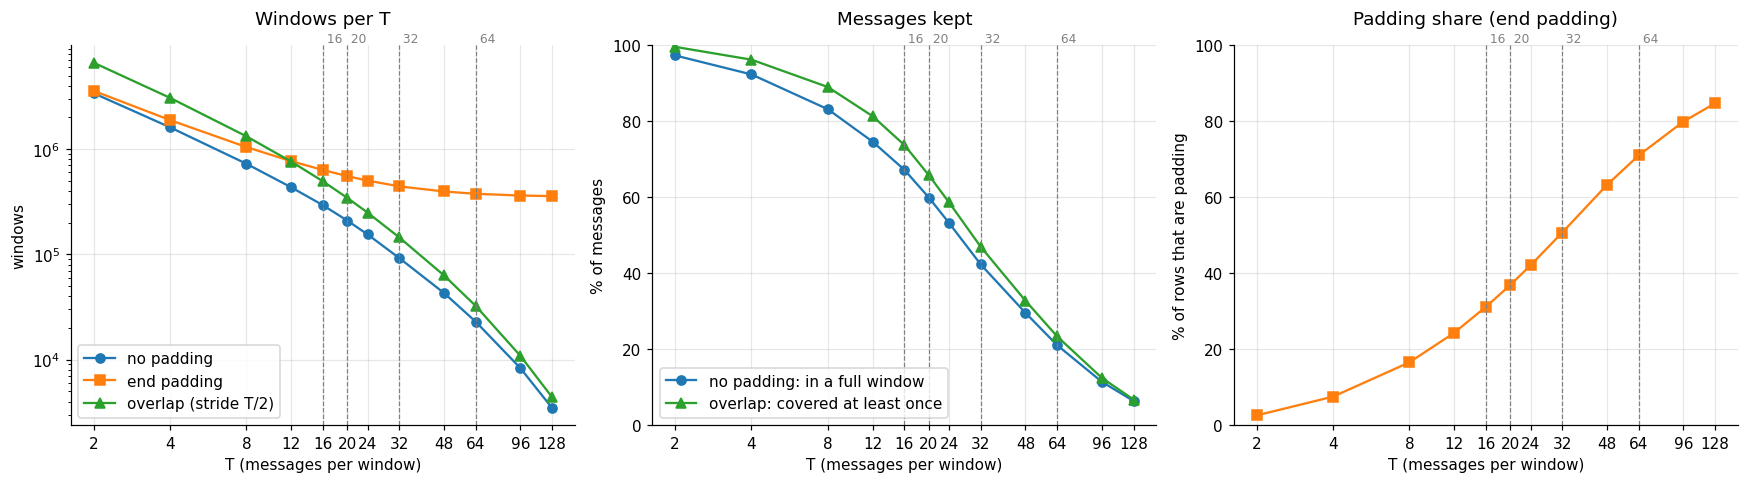

Takeaway: the largest T that still keeps at least half of the messages without padding is T = 24; padding passes 50% fake rows from T = 32.


In [9]:
MARKED_T = [16, 20, 32, 64]


class SweepPlotter:
    """Draws the window-count, message-retention and padding curves of a sweep table."""

    def __init__(self, table: pd.DataFrame, marked: list[int]) -> None:
        """Stores the sweep table and the T values to highlight.

        Args:
            table: Output of `WindowSizeSweep.table()`.
            marked: Window sizes marked with dashed vertical lines.
        """
        self.table = table
        self.marked = marked

    def _mark(self, ax: plt.Axes) -> None:
        for t in self.marked:
            ax.axvline(t, color="grey", ls="--", lw=0.8)
            ax.text(t, 1.0, f" {t}", transform=ax.get_xaxis_transform(), fontsize=8, color="grey", va="bottom")
        ax.set_xscale("log", base=2)
        ax.set_xticks(self.table.index)
        ax.set_xticklabels(self.table.index)
        ax.set_xlabel("T (messages per window)")
        ax.grid(alpha=0.3)

    def plot(self) -> plt.Figure:
        """Returns the three-panel figure."""
        t = self.table.index
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        ax = axes[0]
        ax.plot(t, self.table.windows_no_pad, "o-", label="no padding")
        ax.plot(t, self.table.windows_pad, "s-", label="end padding")
        ax.plot(t, self.table.windows_overlap, "^-", label="overlap (stride T/2)")
        ax.set_yscale("log")
        ax.set_ylabel("windows")
        ax.set_title("Windows per T", pad=14)
        ax.legend()
        ax = axes[1]
        ax.plot(t, 100 * self.table.msgs_used_no_pad, "o-", label="no padding: in a full window")
        ax.plot(t, 100 * self.table.msgs_covered_overlap, "^-", color="C2", label="overlap: covered at least once")
        ax.set_ylabel("% of messages")
        ax.set_ylim(0, 100)
        ax.set_title("Messages kept", pad=14)
        ax.legend()
        ax = axes[2]
        ax.plot(t, 100 * self.table.pad_share_rows, "s-", color="C1")
        ax.set_ylabel("% of rows that are padding")
        ax.set_ylim(0, 100)
        ax.set_title("Padding share (end padding)", pad=14)
        for ax in axes:
            self._mark(ax)
        fig.tight_layout()
        return fig


sweep_fig = SweepPlotter(sweep_table, MARKED_T).plot()
plt.show()

_half = sweep_table[sweep_table.msgs_used_no_pad >= 0.5]
print(
    f"Takeaway: the largest T that still keeps at least half of the messages without padding is "
    f"T = {_half.index.max() if len(_half) else 'none'}; padding passes 50% fake rows from "
    f"T = {sweep_table[sweep_table.pad_share_rows >= 0.5].index.min()}."
)

## Why per-link windows cannot capture DataReplay and DoS

DataReplay and the two DoS attacks change pseudonym every one or two messages, so almost every link they
produce is only one to three messages long. The table gives, for every class and every scenario folder, the
share of links with at least T messages (i.e. that could fill one window). A near-zero share means that class
simply has no windows at that T.

In [10]:
class LinkFillTable:
    """Share of links with at least T messages, per scenario and class."""

    def __init__(self, links: pd.DataFrame, class_order: list[str], t_values: list[int]) -> None:
        """Stores the inputs.

        Args:
            links: Full link table (all scenarios).
            class_order: Classes to report (in this order); others are ignored.
            t_values: Window sizes to test.
        """
        self.links = links[links["cls"].isin(class_order)]
        self.class_order = class_order
        self.t_values = t_values

    def table(self) -> pd.DataFrame:
        """Returns rows (scenario, class) with link count, median length and share of links >= T."""
        grouped = self.links.groupby(["scenario", "cls"])["n_messages"]
        out = pd.DataFrame({"links": grouped.size(), "median_len": grouped.median()})
        for t in self.t_values:
            out[f">= {t}"] = grouped.apply(lambda s, t=t: (s >= t).mean())
        out = out.reset_index()
        out["cls"] = pd.Categorical(out["cls"], self.class_order, ordered=True)
        return out.sort_values(["cls", "scenario"]).set_index(["cls", "scenario"])


fill = LinkFillTable(links, CLASS_ORDER, [2, 4, 8, 16])
fill_table = fill.table()
display(
    formatted(
        fill_table,
        {"links": "{:,.0f}", "median_len": "{:.0f}", **{c: "{:.1%}" for c in fill_table.columns if c.startswith(">=")}},
    )
)

_by_cls = links[links["cls"].isin(CLASS_ORDER)].groupby("cls")["n_messages"]
_share16 = _by_cls.apply(lambda s: (s >= 16).mean()).reindex(CLASS_ORDER)
print(
    "Takeaway: share of links with >= 16 messages, all scenarios: "
    + ", ".join(f"{c} {v:.1%}" for c, v in _share16.items())
    + "."
)

links median_len   >= 2   >= 4   >= 8  >= 16
cls           scenario                                                                 
Benign        DataReplaySybil_0709       103,860         14  94.4%  85.8%  71.4%  46.3%
              DataReplaySybil_1416        21,658         16  94.9%  85.7%  71.8%  50.3%
              DoSDisruptiveSybil_0709    103,859         14  94.4%  85.7%  71.4%  46.3%
              DoSDisruptiveSybil_1416     21,688         16  94.5%  85.7%  71.7%  50.1%
              DoSRandomSybil_0709        103,859         14  94.4%  85.7%  71.4%  46.3%
              DoSRandomSybil_1416         21,688         16  94.5%  85.7%  71.7%  50.1%
              GridSybil_0709             103,971         14  94.5%  86.0%  71.5%  47.0%
              GridSybil_1416              21,699         16  94.7%  85.4%  71.6%  50.1%
GridSybil     GridSybil_0709             184,785         11  91.2%  78.8%  61.0%  37.8%
              GridSybil_1416              43,742         12  92.0%  79.8%  63.7%  42.9%
DataReplay    DataReplaySybil_0709       588,828          1  30.0%   4.7%   0.0%   0.0%
              DataReplaySybil_1416       143,829          1  35.6%   7.8%   0.3%   0.0%
DoSRandom     DoSRandomSybil_0709      1,547,664          1  10.5%   0.1%   0.0%   0.0%
              DoSRandomSybil_1416        381,317          1  18.9%   1.0%   0.0%   0.0%
DoSDisruptive DoSDisruptiveSybil_0709  1,547,646          1  10.5%   0.1%   0.0%   0.0%
              DoSDisruptiveSybil_1416    381,293          1  18.9%   1.0%   0.0%   0.0%

Takeaway: share of links with >= 16 messages, all scenarios: Benign 47.1%, GridSybil 38.8%, DataReplay 0.0%, DoSRandom 0.0%, DoSDisruptive 0.0%.


## How much time does a window span?

Beacons arrive at 1 Hz, so T messages cover about T seconds of driving. TimesNet looks for repeating patterns
inside the window with an FFT; a pattern must repeat at least twice to be seen, so the longest period it can
find is about T/2 seconds (FFT frequency bin 2). Short windows therefore only see very short rhythms.

In [11]:
def time_span_table(t_grid: list[int], rate_hz: float = 1.0) -> pd.DataFrame:
    """Returns the time span and the longest detectable period for each window size.

    Args:
        t_grid: Window sizes in messages.
        rate_hz: Beacon rate in messages per second.

    Returns:
        A table with the window span and the longest period (frequency bin 2) in seconds.
    """
    t = np.asarray(t_grid)
    return pd.DataFrame({"T": t, "span_s": t / rate_hz, "longest_period_s": t / 2 / rate_hz}).set_index("T")


span_table = time_span_table(T_GRID)
for _t, _row in span_table.iterrows():
    print(
        f"T = {_t:>3}: about {_row.span_s:>5.0f} s of driving; longest repeating pattern about "
        f"{_row.longest_period_s:>4.0f} s"
    )
print(
    f"Takeaway: at 1 Hz, T = 64 spans about {span_table.loc[64, 'span_s']:.0f} s and can show periods up to "
    f"about {span_table.loc[64, 'longest_period_s']:.0f} s; T = 16 only up to "
    f"{span_table.loc[16, 'longest_period_s']:.0f} s."
)

T =   2: about     2 s of driving; longest repeating pattern about    1 s
T =   4: about     4 s of driving; longest repeating pattern about    2 s
T =   8: about     8 s of driving; longest repeating pattern about    4 s
T =  12: about    12 s of driving; longest repeating pattern about    6 s
T =  16: about    16 s of driving; longest repeating pattern about    8 s
T =  20: about    20 s of driving; longest repeating pattern about   10 s
T =  24: about    24 s of driving; longest repeating pattern about   12 s
T =  32: about    32 s of driving; longest repeating pattern about   16 s
T =  48: about    48 s of driving; longest repeating pattern about   24 s
T =  64: about    64 s of driving; longest repeating pattern about   32 s
T =  96: about    96 s of driving; longest repeating pattern about   48 s
T = 128: about   128 s of driving; longest repeating pattern about   64 s
Takeaway: at 1 Hz, T = 64 spans about 64 s and can show periods up to about 32 s; T = 16 only up to 8 s.


## Class and split balance for each window size T

A window is T consecutive messages of one link, cut without overlap and without padding, so a link of
n messages gives n // T windows (the leftover messages are dropped). We count windows only in the two
GridSybil folders and only for the classes the encoder sees (Benign and GridSybil). For every T we show
the share of each class, the imbalance ratio (majority windows / minority windows), and the inverse-frequency
class weights a loss would use on the train split.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SPLITS = ["train", "pretrain_val", "val", "test"]
CANDIDATE_T = [16, 20, 32, 64]


def windows_without_padding(n_messages: np.ndarray, t: int) -> np.ndarray:
    """Number of full, non-overlapping windows of length t in links of the given lengths."""
    return n_messages // t


def windows_with_padding(n_messages: np.ndarray, t: int) -> np.ndarray:
    """Number of windows when the last partial window of each link is padded at the end."""
    return -(-n_messages // t)


class WindowTable:
    """Per-link window counts for every T, on the encoder subset of the links table.

    Attributes:
        links: Links from the GridSybil folders whose class is an encoder class.
        t_grid: Window sizes that are evaluated.
        windows: Maps T to an array with the number of unpadded windows of each link.
    """

    def __init__(self, all_links: pd.DataFrame, classes: list[str], t_grid: list[int]) -> None:
        in_folders = all_links["scenario"].str.startswith("GridSybil")
        in_classes = all_links["cls"].isin(classes)
        self.links = all_links.loc[in_folders & in_classes].reset_index(drop=True)
        self.classes = list(classes)
        self.t_grid = list(t_grid)
        lengths = self.links["n_messages"].to_numpy()
        self.windows = {t: windows_without_padding(lengths, t) for t in self.t_grid}

    def count(self, t: int, by: list[str]) -> pd.Series:
        """Total windows at T, grouped by the given columns."""
        return pd.Series(self.windows[t]).groupby([self.links[c] for c in by]).sum()

    def kept(self, t: int) -> pd.DataFrame:
        """Links that still give at least one window at T."""
        return self.links.loc[self.windows[t] > 0]


class BalanceReport:
    """Class shares, imbalance ratios and class weights of the windows, per T and per split."""

    def __init__(self, table: WindowTable) -> None:
        self.table = table

    def _per_class(self, t: int, mask: np.ndarray | None = None) -> pd.Series:
        windows = self.table.windows[t] if mask is None else self.table.windows[t][mask]
        classes = self.table.links["cls"] if mask is None else self.table.links["cls"][mask]
        totals = pd.Series(windows).groupby(classes.to_numpy()).sum()
        return totals.reindex(self.table.classes, fill_value=0)

    @staticmethod
    def _summarise(per_class: pd.Series) -> dict:
        total = int(per_class.sum())
        row = {f"{name} windows": int(value) for name, value in per_class.items()}
        row["total windows"] = total
        row["Benign share"] = per_class["Benign"] / total if total else np.nan
        minority = per_class.min()
        row["imbalance ratio"] = per_class.max() / minority if minority else np.inf
        row["majority class"] = per_class.idxmax()
        return row

    def overall(self) -> pd.DataFrame:
        """One row per T for all windows of the encoder subset."""
        rows = {t: self._summarise(self._per_class(t)) for t in self.table.t_grid}
        return pd.DataFrame.from_dict(rows, orient="index").rename_axis("T")

    def by_split(self) -> pd.DataFrame:
        """One row per (T, split)."""
        split_column = self.table.links["split"].to_numpy()
        rows = {}
        for t in self.table.t_grid:
            for split in SPLITS:
                rows[(t, split)] = self._summarise(self._per_class(t, split_column == split))
        frame = pd.DataFrame.from_dict(rows, orient="index")
        frame.index = pd.MultiIndex.from_tuples(frame.index, names=["T", "split"])
        return frame

    def train_class_weights(self) -> pd.DataFrame:
        """Inverse-frequency weights on the train split: N / (n_classes * n_class)."""
        split_column = self.table.links["split"].to_numpy()
        rows = {}
        for t in self.table.t_grid:
            per_class = self._per_class(t, split_column == "train")
            total = per_class.sum()
            rows[t] = {name: total / (len(per_class) * value) if value else np.inf for name, value in per_class.items()}
        return pd.DataFrame.from_dict(rows, orient="index").rename_axis("T")

    def split_counts(self, t_values: list[int]) -> pd.DataFrame:
        """Windows per split and class for a few T values (rows: T and class; columns: splits)."""
        counts = {t: self.table.count(t, ["cls", "split"]).unstack("split", fill_value=0) for t in t_values}
        frame = pd.concat(counts, names=["T", "class"])
        columns = [s for s in SPLITS + ["none"] if s in frame.columns]
        frame = frame.reindex(columns=columns, fill_value=0)
        frame["all"] = frame.sum(axis=1)
        return frame


window_table = WindowTable(links, ENCODER_CLASSES, T_GRID)
balance = BalanceReport(window_table)
balance_overall = balance.overall()
balance_by_split = balance.by_split()
train_weights = balance.train_class_weights()

display(balance_overall.round(3))

,Benign windows,GridSybil windows,total windows,Benign share,imbalance ratio,majority class
T,,,,,,
2,1275667,2122266,3397933,0.38,1.66,GridSybil
4,606757,1004885,1611642,0.38,1.66,GridSybil
8,274012,451788,725800,0.38,1.65,GridSybil
12,163861,270396,434257,0.38,1.65,GridSybil
16,110326,183116,293442,0.38,1.66,GridSybil
20,78376,130750,209126,0.38,1.67,GridSybil
24,57485,97420,154905,0.37,1.70,GridSybil
32,33035,59285,92320,0.36,1.79,GridSybil
48,14749,28277,43026,0.34,1.92,GridSybil


In [13]:
benign_share_by_split = balance_by_split["Benign share"].unstack("split")[SPLITS]
display((benign_share_by_split * 100).round(1).rename(columns=lambda s: f"{s} Benign %"))
display(train_weights.round(3).rename(columns=lambda c: f"{c} weight"))
display(balance.split_counts(CANDIDATE_T))

first_t, last_t = T_GRID[0], T_GRID[-1]
spread = (benign_share_by_split.max(axis=1) - benign_share_by_split.min(axis=1)) * 100
print(
    f"Takeaway: the Benign share of windows moves from {balance_overall.loc[first_t, 'Benign share']:.1%} "
    f"at T = {first_t} to {balance_overall.loc[last_t, 'Benign share']:.1%} at T = {last_t}; "
    f"the imbalance ratio goes from {balance_overall.loc[first_t, 'imbalance ratio']:.2f} to "
    f"{balance_overall.loc[last_t, 'imbalance ratio']:.2f} (majority: "
    f"{balance_overall.loc[last_t, 'majority class']} at T = {last_t}). Across splits the Benign share differs "
    f"by at most {spread.max():.1f} points (largest gap at T = {spread.idxmax()})."
)

split,train Benign %,pretrain_val Benign %,val Benign %,test Benign %
T,,,,
2,38.10,33.30,35.40,39.90
4,38.20,33.50,35.40,40.00
8,38.30,33.60,35.40,40.00
12,38.30,33.80,35.10,40.10
16,38.20,33.80,34.90,39.80
20,38.10,33.80,34.60,39.70
24,37.90,33.40,34.10,39.00
32,36.70,32.70,32.60,36.90
48,35.40,31.30,30.20,35.30


,Benign weight,GridSybil weight
T,,
2,1.31,0.81
4,1.31,0.81
8,1.31,0.81
12,1.30,0.81
16,1.31,0.81
20,1.31,0.81
24,1.32,0.81
32,1.36,0.79
48,1.41,0.77


split          train  pretrain_val    val   test     all
T  class                                                
16 Benign      70360          7388  15916  16662  110326
   GridSybil  113741         14461  29670  25244  183116
20 Benign      49997          5252  11244  11883   78376
   GridSybil   81160         10267  21238  18085  130750
32 Benign      21077          2285   4698   4975   33035
   GridSybil   36382          4702   9698   8503   59285
64 Benign       4776           481   1066   1111    7434
   GridSybil    9349          1232   2569   2392   15542

Takeaway: the Benign share of windows moves from 37.5% at T = 2 to 23.8% at T = 128; the imbalance ratio goes from 1.66 to 3.21 (majority: GridSybil at T = 128). Across splits the Benign share differs by at most 7.2 points (largest gap at T = 128).


## Does a longer T change who is represented?

A long T throws away short links, and with them some vehicles may disappear entirely. Here we count the
distinct sender vehicles and the distinct receivers that still have at least one window, per T and per class,
compared with all vehicles that have any link. A vehicle is identified by (time group, vehicle id), the same
key the split uses. The second table checks whether the split still holds about 70% of senders in train
(of which 10% are pretrain_val), 15% in val and 15% in test, among the senders that survive at each T.

In [14]:
class CoverageReport:
    """Which sender vehicles and receivers still have windows at each T, and how they fall into splits."""

    TARGET = {"train (incl. pretrain_val)": 0.70, "pretrain_val / train": 0.10, "val": 0.15, "test": 0.15}

    def __init__(self, table: WindowTable) -> None:
        self.table = table

    @staticmethod
    def _distinct(frame: pd.DataFrame, column: str) -> int:
        return len(frame[["group", column]].drop_duplicates())

    def vehicles(self) -> pd.DataFrame:
        """Senders and receivers present per (T, class), with the share of the full set and the number lost."""
        everything = self.table.links
        rows = {}
        for t in self.table.t_grid:
            kept = self.table.kept(t)
            for name in self.table.classes:
                base, now = everything[everything["cls"] == name], kept[kept["cls"] == name]
                senders_base, senders_now = self._distinct(base, "sender"), self._distinct(now, "sender")
                receivers_base, receivers_now = self._distinct(base, "receiver"), self._distinct(now, "receiver")
                rows[(t, name)] = {
                    "senders": senders_now,
                    "senders share": senders_now / senders_base,
                    "senders lost": senders_base - senders_now,
                    "receivers": receivers_now,
                    "receivers share": receivers_now / receivers_base,
                    "receivers lost": receivers_base - receivers_now,
                }
        frame = pd.DataFrame.from_dict(rows, orient="index")
        frame.index = pd.MultiIndex.from_tuples(frame.index, names=["T", "class"])
        return frame

    def split_fractions(self) -> pd.DataFrame:
        """Fractions of surviving sender vehicles in each split, per T, and the largest gap to the target."""
        rows = {}
        for t in self.table.t_grid:
            senders = self.table.kept(t)[["group", "sender", "split"]].drop_duplicates()
            share = senders["split"].value_counts(normalize=True)
            train_all = share.get("train", 0.0) + share.get("pretrain_val", 0.0)
            row = {
                "senders": len(senders),
                "train (incl. pretrain_val)": train_all,
                "pretrain_val / train": share.get("pretrain_val", 0.0) / train_all if train_all else np.nan,
                "val": share.get("val", 0.0),
                "test": share.get("test", 0.0),
                "no split": share.get("none", 0.0),
            }
            row["largest gap to target"] = max(abs(row[k] - v) for k, v in self.TARGET.items())
            rows[t] = row
        return pd.DataFrame.from_dict(rows, orient="index").rename_axis("T")


coverage = CoverageReport(window_table)
coverage_vehicles = coverage.vehicles()
split_fractions = coverage.split_fractions()
display(coverage_vehicles.round(3))
display(split_fractions.round(3))

sender_share = coverage_vehicles["senders share"].unstack("class")
worst_gap = split_fractions["largest gap to target"]
print(
    "Takeaway: at T = "
    + ", ".join(
        f"{t}: " + " / ".join(f"{c} {sender_share.loc[t, c]:.0%}" for c in ENCODER_CLASSES) for t in CANDIDATE_T
    )
    + " of sender vehicles still have a window. The split fractions stay within "
    f"{worst_gap.max() * 100:.1f} points of 70/10/15/15 for every T (worst at T = {worst_gap.idxmax()})."
)

senders  senders share  senders lost  receivers  receivers share  receivers lost
T   class                                                                                      
2   Benign        4013           1.00            13       5734             1.00              14
    GridSybil     1724           1.00             2       5685             1.00              13
4   Benign        3999           0.99            27       5711             0.99              37
    GridSybil     1719           1.00             7       5637             0.99              61
8   Benign        3971           0.99            55       5661             0.98              87
    GridSybil     1708           0.99            18       5558             0.97             140
12  Benign        3901           0.97           125       5550             0.97             198
    GridSybil     1687           0.98            39       5444             0.95             254
16  Benign        3819           0.95           207       5416             0.94             332
    GridSybil     1655           0.96            71       5296             0.93             402
20  Benign        3722           0.92           304       5254             0.91             494
    GridSybil     1617           0.94           109       5103             0.90             595
24  Benign        3555           0.88           471       4982             0.87             766
    GridSybil     1562           0.91           164       4892             0.86             806
32  Benign        3289           0.82           737       4479             0.78            1269
    GridSybil     1463           0.85           263       4446             0.78            1252
48  Benign        2776           0.69          1250       3627             0.63            2121
    GridSybil     1297           0.75           429       3703             0.65            1995
64  Benign        2106           0.52          1920       2672             0.47            3076
    GridSybil     1073           0.62           653       2979             0.52            2719
96  Benign        1115           0.28          2911       1357             0.24            4391
    GridSybil      721           0.42          1005       1850             0.33            3848
128 Benign         501           0.12          3525        574             0.10            5174
    GridSybil      469           0.27          1257       1173             0.21            4525

,senders,train (incl. pretrain_val),pretrain_val / train,val,test,no split,largest gap to target
T,,,,,,,
2,5737,0.70,0.10,0.15,0.15,0.00,0.00
4,5718,0.70,0.10,0.15,0.15,0.00,0.00
8,5679,0.70,0.10,0.15,0.15,0.00,0.00
12,5588,0.70,0.10,0.15,0.15,0.00,0.00
16,5474,0.70,0.10,0.15,0.15,0.00,0.00
20,5339,0.70,0.10,0.15,0.15,0.00,0.00
24,5117,0.70,0.10,0.15,0.15,0.00,0.00
32,4752,0.70,0.10,0.15,0.15,0.00,0.00
48,4073,0.71,0.10,0.14,0.14,0.00,0.01


Takeaway: at T = 16: Benign 95% / GridSybil 96%, 20: Benign 92% / GridSybil 94%, 32: Benign 82% / GridSybil 85%, 64: Benign 52% / GridSybil 62% of sender vehicles still have a window. The split fractions stay within 1.2 points of 70/10/15/15 for every T (worst at T = 96).


## Balance and coverage at a glance

Left: the share of Benign windows for each T, for all windows (thick line) and for each split (thin lines);
lines that stay together mean the splits keep the same class mix. Right: the share of sender vehicles
(solid) and receivers (dashed) that still have at least one window, per class. The x axis is logarithmic
because T doubles along most of the grid.

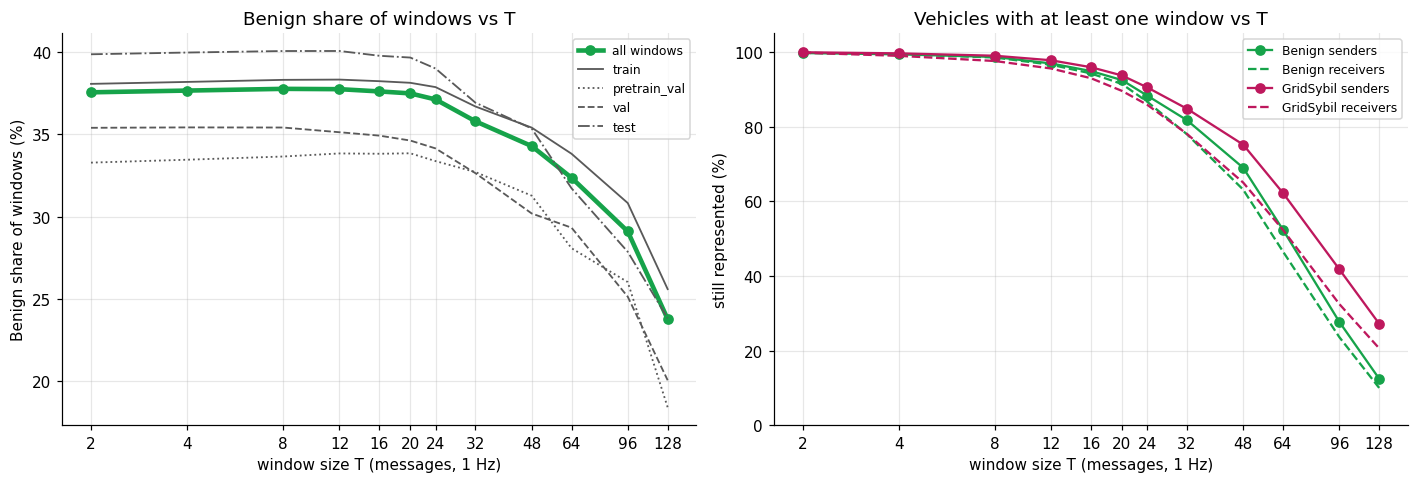

In [15]:
class BalancePlots:
    """Two figures: Benign share versus T, and vehicles represented versus T."""

    SPLIT_STYLES = {"train": "-", "pretrain_val": ":", "val": "--", "test": "-."}

    def __init__(
        self, overall: pd.DataFrame, by_split: pd.DataFrame, vehicles: pd.DataFrame, colors: dict[str, str]
    ) -> None:
        self.overall, self.by_split, self.vehicles, self.colors = overall, by_split, vehicles, colors

    @staticmethod
    def _t_axis(ax: plt.Axes, t_values: list[int]) -> None:
        ax.set_xscale("log", base=2)
        ax.set_xticks(t_values)
        ax.set_xticklabels([str(t) for t in t_values])
        ax.set_xlabel("window size T (messages, 1 Hz)")
        ax.grid(alpha=0.3)

    def draw(self) -> plt.Figure:
        fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
        t_values = list(self.overall.index)
        left.plot(
            t_values,
            self.overall["Benign share"] * 100,
            color=self.colors["Benign"],
            lw=3,
            marker="o",
            label="all windows",
        )
        shares = self.by_split["Benign share"].unstack("split")
        for split, style in self.SPLIT_STYLES.items():
            left.plot(t_values, shares[split] * 100, color="0.35", ls=style, lw=1.2, label=split)
        left.set_ylabel("Benign share of windows (%)")
        left.set_title("Benign share of windows vs T")
        left.legend(fontsize=8)
        self._t_axis(left, t_values)

        for name in self.vehicles.index.get_level_values("class").unique():
            part = self.vehicles.xs(name, level="class")
            right.plot(
                part.index, part["senders share"] * 100, color=self.colors[name], marker="o", label=f"{name} senders"
            )
            right.plot(
                part.index, part["receivers share"] * 100, color=self.colors[name], ls="--", label=f"{name} receivers"
            )
        right.set_ylabel("still represented (%)")
        right.set_ylim(0, 105)
        right.set_title("Vehicles with at least one window vs T")
        right.legend(fontsize=8)
        self._t_axis(right, t_values)
        fig.tight_layout()
        return fig


BalancePlots(balance_overall, balance_by_split, coverage_vehicles, CLASS_COLOURS).draw()
plt.show()

## Choosing T

Small T keeps almost every link, so there are more windows, more messages used and a class mix close to the
raw data; but each window is short, so the encoder only sees short stretches of motion and can only find
periods up to T/2 seconds. Large T gives long trajectories and longer detectable periods, but drops most
short links (or, if padded, fills much of each window with padding) and shifts the class mix. The table puts
these numbers side by side for the candidate sizes; the decision is left to the reader.

In [16]:
class TChoiceSummary:
    """Side-by-side numbers for candidate window sizes."""

    def __init__(self, table: WindowTable, overall: pd.DataFrame) -> None:
        self.table, self.overall = table, overall
        self.lengths = table.links["n_messages"].to_numpy()

    def row(self, t: int) -> dict:
        unpadded = windows_without_padding(self.lengths, t)
        padded = windows_with_padding(self.lengths, t)
        slots = int(padded.sum()) * t
        return {
            "windows (no padding)": int(unpadded.sum()),
            "messages used": unpadded.sum() * t / self.lengths.sum(),
            "links used": (unpadded > 0).mean(),
            "windows (end padding)": int(padded.sum()),
            "padding share if padded": (slots - self.lengths.sum()) / slots,
            "Benign share": self.overall.loc[t, "Benign share"],
            "longest detectable period (s)": t / 2,
        }

    def table_for(self, t_values: list[int]) -> pd.DataFrame:
        return pd.DataFrame.from_dict({t: self.row(t) for t in t_values}, orient="index").rename_axis("T")

    def t_with_message_share(self, minimum: float) -> list[int]:
        """All T in the grid that use at least `minimum` of the messages without padding."""
        return [t for t in self.table.t_grid if self.row(t)["messages used"] >= minimum]

    def closest_benign_share(self, reference_t: int, t_values: list[int]) -> int:
        """The T (other than the reference) whose Benign share is closest to the share at reference_t."""
        reference = self.overall.loc[reference_t, "Benign share"]
        others = [t for t in t_values if t != reference_t]
        return min(others, key=lambda t: abs(self.overall.loc[t, "Benign share"] - reference))


summary = TChoiceSummary(window_table, balance_overall)
choice_table = summary.table_for(CANDIDATE_T)
percent_columns = ["messages used", "links used", "padding share if padded", "Benign share"]
display(
    choice_table.assign(**{c: (choice_table[c] * 100).round(1) for c in percent_columns}).rename(
        columns={c: f"{c} (%)" for c in percent_columns}
    )
)

half_messages = summary.t_with_message_share(0.5)
reference_t = T_GRID[0]
closest_candidate = summary.closest_benign_share(reference_t, CANDIDATE_T)
closest_grid = summary.closest_benign_share(reference_t, T_GRID)
print(
    f"T values that use at least 50% of the messages without padding: {half_messages} "
    f"(largest: {max(half_messages) if half_messages else 'none'})."
)
print(
    f"Benign share at T = {reference_t}: {balance_overall.loc[reference_t, 'Benign share']:.1%}. Closest among "
    f"{CANDIDATE_T}: T = {closest_candidate} ({balance_overall.loc[closest_candidate, 'Benign share']:.1%}); "
    f"closest on the whole grid: T = {closest_grid} ({balance_overall.loc[closest_grid, 'Benign share']:.1%})."
)

,windows (no padding),messages used (%),links used (%),windows (end padding),padding share if padded (%),Benign share (%),longest detectable period (s)
T,,,,,,,
16,293442,67.30,41.90,633677,31.20,37.60,8.00
20,209126,59.90,32.70,553489,36.90,37.50,10.00
32,92320,42.30,16.90,442701,50.70,35.80,16.00
64,22976,21.10,5.20,376427,71.00,32.40,32.00


T values that use at least 50% of the messages without padding: [2, 4, 8, 12, 16, 20, 24] (largest: 24).
Benign share at T = 2: 37.5%. Closest among [16, 20, 32, 64]: T = 16 (37.6%); closest on the whole grid: T = 16 (37.6%).
